In [1]:
import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [2]:
# ── Edit this path ──────────────────────────────────────────────────────────
QV_PATH = "../scripts/examples/example_inputs/3_rf2.qv"
# ────────────────────────────────────────────────────────────────────────────

paes, rmsds, tags = [], [], []

with open(QV_PATH) as f:
    for line in f:
        if not line.startswith("QV_SCORE"):
            continue
        parts = line.split()
        tag = parts[1]
        scores = {}
        # All key=value pairs are pipe-separated in parts[2]
        for kv in parts[2].split("|"):
            k, _, v = kv.partition("=")
            try:
                scores[k] = float(v)
            except ValueError:
                pass
        pae  = scores.get("interaction_pae")
        rmsd = scores.get("framework_aligned_cdr_rmsd")
        if pae is not None and rmsd is not None and not np.isnan(rmsd):
            paes.append(pae)
            rmsds.append(rmsd)
            tags.append(tag)

paes  = np.array(paes)
rmsds = np.array(rmsds)
print(f"Loaded {len(paes)} designs")
print(f"pAE  range: {paes.min():.1f} – {paes.max():.1f}")
print(f"RMSD range: {rmsds.min():.2f} – {rmsds.max():.2f} Å")


Loaded 1000 designs
pAE  range: 5.5 – 24.6
RMSD range: 0.46 – 3.35 Å


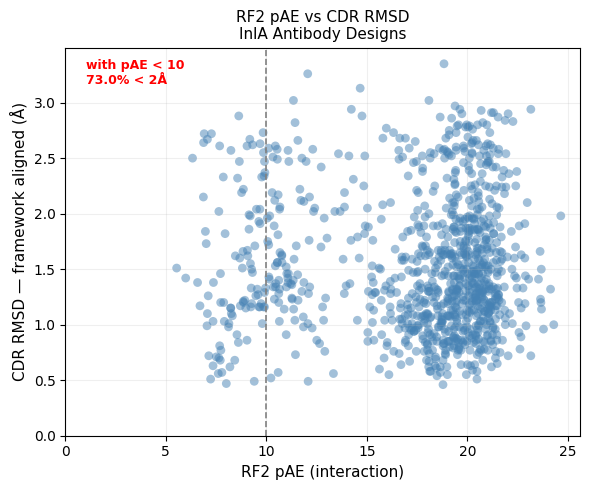

Designs with pAE < 10.0: 100 (10.0%)


In [3]:
PAE_THRESH  = 10.0
RMSD_THRESH = 2.0

low_pae_mask = paes < PAE_THRESH
n_low_pae    = low_pae_mask.sum()
pct = 100 * (rmsds[low_pae_mask] < RMSD_THRESH).sum() / n_low_pae if n_low_pae > 0 else 0
annotation = f"with pAE < {PAE_THRESH:.0f}\n{pct:.1f}% < {RMSD_THRESH:.0f}Å"

fig, ax = plt.subplots(figsize=(6, 5))

ax.scatter(paes, rmsds, alpha=0.5, s=40, color="steelblue", edgecolors="none")
ax.axvline(x=PAE_THRESH, color="gray", linestyle="--", linewidth=1.2)
ax.text(0.04, 0.97, annotation,
        transform=ax.transAxes, va="top", ha="left",
        color="red", fontsize=9, fontweight="bold")

ax.set_xlabel("RF2 pAE (interaction)", fontsize=11)
ax.set_ylabel("CDR RMSD — framework aligned (Å)", fontsize=11)
ax.set_title("RF2 pAE vs CDR RMSD\nInlA Antibody Designs", fontsize=11)
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig("rf2_pae_vs_rmsd.png", dpi=150)
plt.show()
print(f"Designs with pAE < {PAE_THRESH}: {n_low_pae} ({100*n_low_pae/len(paes):.1f}%)")

In [4]:
# Top designs: lowest pAE + lowest RMSD
combined_rank = paes + rmsds
top_idx = np.argsort(combined_rank)[:10]

print("Top 10 designs (lowest pAE + RMSD):")
print(f"{'Tag':<50} {'pAE':>6} {'RMSD':>7}")
print("-" * 66)
for i in top_idx:
    print(f"{tags[i]:<50} {paes[i]:>6.2f} {rmsds[i]:>6.2f}Å")

Top 10 designs (lowest pAE + RMSD):
Tag                                                   pAE    RMSD
------------------------------------------------------------------
samples_design_79_dldesign_9_best                    5.54   1.51Å
samples_design_79_dldesign_2_best                    5.99   1.42Å
samples_design_86_dldesign_9_best                    7.23   0.51Å
samples_design_3_dldesign_9_best                     7.14   0.72Å
samples_design_66_dldesign_3_best                    6.70   1.17Å
samples_design_32_dldesign_3_best                    6.58   1.38Å
samples_design_86_dldesign_6_best                    7.35   0.63Å
samples_design_46_dldesign_6_best                    7.05   0.99Å
samples_design_86_dldesign_4_best                    7.61   0.56Å
samples_design_32_dldesign_2_best                    7.07   1.10Å
